In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import drive
drive.mount('/content/drive')
import os
os.listdir('/content/drive/MyDrive/Wafer_Dataset')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['LSWMD.pkl']

In [ ]:
import pandas as pd

data = pd.read_pickle('/content/drive/MyDrive/Wafer_Dataset/LSWMD.pkl')

In [ ]:
data.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [ ]:
print(data.shape)
print(data.columns)

(811457, 6)
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


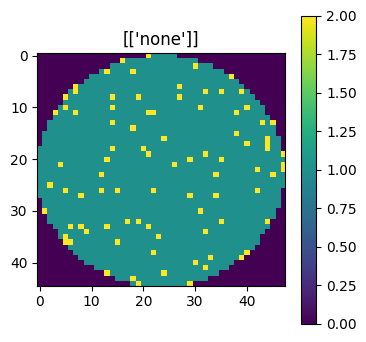

In [ ]:
import matplotlib.pyplot as plt

sample_wafer = data['waferMap'].iloc[0]

plt.figure(figsize=(4,4))
plt.imshow(sample_wafer)
plt.title(data['failureType'].iloc[0])
plt.colorbar()
plt.show()

In [ ]:
data = pd.read_pickle('LSWMD.pkl')
data.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [ ]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(data.columns)
print(data.shape)
data.head()

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')
(811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [ ]:
print(data['failureType'].head())
print(data['waferMap'].head())

0    [[none]]
1    [[none]]
2    [[none]]
3    [[none]]
4    [[none]]
Name: failureType, dtype: object
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
1    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
2    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
3    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
4    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Name: waferMap, dtype: object


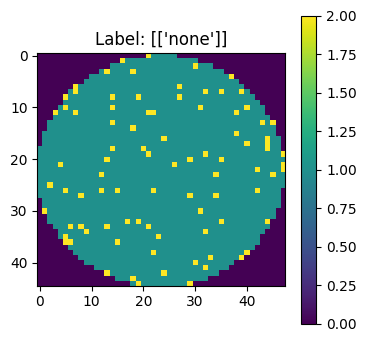

In [ ]:
sample_wafer = data['waferMap'].iloc[0]

plt.figure(figsize=(4,4))
plt.imshow(sample_wafer)
plt.title(f"Label: {data['failureType'].iloc[0]}")
plt.colorbar()
plt.show()

In [ ]:
# Keep only rows with non-null labels
data = data[data['failureType'].notna()].copy()

# Convert labels into simple strings
def clean_label(x):
    if isinstance(x, list) or isinstance(x, np.ndarray):
        if len(x) > 0:
            return str(x[0])
    return str(x)

data['failureType'] = data['failureType'].apply(clean_label)

print(data['failureType'].value_counts())

failureType
[]               638507
['none']         147431
['Edge-Ring']      9680
['Edge-Loc']       5189
['Center']         4294
['Loc']            3593
['Scratch']        1193
['Random']          866
['Donut']           555
['Near-full']       149
Name: count, dtype: int64


In [ ]:
target_classes = ['Center', 'Donut', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

data = data[data['failureType'].isin(target_classes)].copy()

print(data['failureType'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
if not data.empty:
    number_of_samples = len(data)
    # Assuming all waferMaps have the same dimensions
    height, width = data['waferMap'].iloc[0].shape
    channels = 1 # Assuming grayscale images

    print(f"Number of samples: {number_of_samples}")
    print(f"Image height: {height}")
    print(f"Image width: {width}")
    print(f"Number of channels: {channels}")
else:
    print("Error: The 'data' DataFrame is empty. Please ensure data is loaded and filtered correctly before attempting to get its dimensions.")

NameError: name 'number_of_samples' is not defined

In [ ]:
X = []
for wafer in data['waferMap']:
    wafer_array = np.array(wafer)
    X.append(wafer_array)

X = np.array(X)
print(X.shape)

(0,)


In [ ]:
X = X[..., np.newaxis]
print(X.shape)


(0, 1)


In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['failureType'])

print(label_encoder.classes_)
print(y[:10])

[]
[]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
print("data shape:", data.shape)
print("X shape:", X.shape if 'X' in globals() else "X not created")
print("y shape:", y.shape if 'y' in globals() else "y not created")

data shape: (0, 6)
X shape: (0, 1)
y shape: (0,)


In [ ]:
print(data['failureType'].head(20))

Series([], Name: failureType, dtype: object)


In [ ]:
print(data['failureType'].value_counts(dropna=False).head(20))


Series([], Name: count, dtype: int64)


In [ ]:
import numpy as np
import pandas as pd

def clean_label(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return None
        return str(x.flatten()[0]).strip()
    elif isinstance(x, list):
        if len(x) == 0:
            return None
        return str(x[0]).strip()
    elif pd.isna(x):
        return None
    else:
        return str(x).strip()

data['failureType_clean'] = data['failureType'].apply(clean_label)
print(data['failureType_clean'].value_counts(dropna=False).head(20))

Series([], Name: count, dtype: int64)


In [ ]:
target_classes = ['Center', 'Donut', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

data_filtered = data[data['failureType_clean'].isin(target_classes)].copy()

print("Filtered shape:", data_filtered.shape)
print(data_filtered['failureType_clean'].value_counts())

Filtered shape: (0, 7)
Series([], Name: count, dtype: int64)


In [ ]:
X = []
for wafer in data_filtered['waferMap']:
    X.append(np.array(wafer))

X = np.array(X)
X = X[..., np.newaxis]

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data_filtered['failureType_clean'])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", label_encoder.classes_)

X shape: (0, 1)
y shape: (0,)
Classes: []


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [1]:
print(data['failureType'].head(10))
print(data['failureType'].value_counts(dropna=False).head(20))

NameError: name 'data' is not defined

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
os.listdir('/content/drive/MyDrive/Wafer_Dataset')

['LSWMD.pkl']

In [4]:
data = pd.read_pickle('/content/drive/MyDrive/Wafer_Dataset/LSWMD.pkl')

In [5]:
print(type(data))
print(data.shape)
print(data.columns)
data.head()

<class 'pandas.core.frame.DataFrame'>
(811457, 6)
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [ ]:
print(data['failureType'].head(10))
print(data['failureType'].value_counts(dropna=False).head(20))

0    [[none]]
1    [[none]]
2    [[none]]
3    [[none]]
4    [[none]]
5    [[none]]
6    [[none]]
7    [[none]]
8    [[none]]
9    [[none]]
Name: failureType, dtype: object


In [1]:
def clean_label(x):
    try:
        return x[0][0]
    except:
        return "none"

data["failureType_clean"] = data["failureType"].apply(clean_label)

print(data["failureType_clean"].value_counts().head(20))


NameError: name 'data' is not defined

In [2]:
import pandas as pd

data = pd.read_pickle('/content/drive/MyDrive/Wafer_Dataset/LSWMD.pkl')


In [3]:
print(data.shape)
data.head()

(811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [4]:
def clean_label(x):
    try:
        return x[0][0]
    except:
        return "none"

data["failureType_clean"] = data["failureType"].apply(clean_label)

print(data["failureType_clean"].value_counts().head(20))


failureType_clean
none         785938
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [6]:
data_filtered = data[data["failureType_clean"] != "none"]

print("Filtered shape:", data_filtered.shape)
print(data_filtered["failureType_clean"].value_counts())


Filtered shape: (25519, 7)
failureType_clean
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [8]:
data_filtered = data[data["failureType_clean"] != "none"]

print("Filtered shape:", data_filtered.shape)
print(data_filtered["failureType_clean"].value_counts())

Filtered shape: (25519, 7)
failureType_clean
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [9]:
import numpy as np

X = []

for wafer in data_filtered["waferMap"]:
    X.append(np.array(wafer))

X = np.array(X)

# add channel dimension for CNN
X = X[..., np.newaxis]

print("X shape:", X.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (25519,) + inhomogeneous part.

In [10]:
wafer_shapes = data_filtered["waferMap"].apply(lambda x: np.array(x).shape)

print(wafer_shapes.value_counts().head(20))

waferMap
(25, 27)      2900
(38, 36)      2127
(53, 52)      1519
(63, 62)      1424
(39, 37)      1015
(26, 26)       877
(30, 34)       710
(35, 31)       648
(44, 41)       600
(29, 26)       555
(41, 41)       527
(69, 73)       484
(107, 150)     470
(41, 42)       465
(46, 46)       454
(39, 31)       453
(43, 42)       453
(34, 34)       442
(32, 29)       413
(35, 40)       405
Name: count, dtype: int64


In [11]:
most_common_shape = wafer_shapes.value_counts().idxmax()
print("Most common shape:", most_common_shape)

data_fixed = data_filtered[wafer_shapes == most_common_shape].copy()

print("Fixed dataset shape:", data_fixed.shape)

Most common shape: (25, 27)
Fixed dataset shape: (2900, 7)


In [12]:
X = []

for wafer in data_fixed["waferMap"]:
    X.append(np.array(wafer))

X = np.array(X)

# add channel dimension for CNN
X = X[..., np.newaxis]

print("X shape:", X.shape)

X shape: (2900, 25, 27, 1)


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(data_fixed["failureType_clean"])

print("y shape:", y.shape)
print("Classes:", label_encoder.classes_)

y shape: (2900,)
Classes: [np.str_('Center') np.str_('Edge-Loc') np.str_('Edge-Ring') np.str_('Loc')
 np.str_('Near-full') np.str_('Random') np.str_('Scratch')]


In [14]:
print("Most common shape:", most_common_shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Most common shape: (25, 27)
X shape: (2900, 25, 27, 1)
y shape: (2900,)


In [16]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train = X_train / X_train.max()
X_test = X_test / X_test.max()

print("Train max:", X_train.max())
print("Test max:", X_test.max())

Train max: 1.0
Test max: 1.0


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(np.unique(y))

model = models.Sequential([
    layers.Input(shape=(25, 27, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 23, 25, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 10, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,255 (395.53 KB)

 Trainable params: 101,255 (395.53 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7184 - loss: 1.0765 - val_accuracy: 0.7759 - val_loss: 0.7918
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7820 - loss: 0.7693 - val_accuracy: 0.7759 - val_loss: 0.5864
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8252 - loss: 0.5324 - val_accuracy: 0.8690 - val_loss: 0.4081
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8623 - loss: 0.4296 - val_accuracy: 0.9086 - val_loss: 0.3472
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8920 - loss: 0.3385 - val_accuracy: 0.8983 - val_loss: 0.3005
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8940 - loss: 0.3263 - val_accuracy: 0.8879 - val_loss: 0.3113
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9009 - loss: 0.2878 - val_accuracy: 0.9103 - val_loss: 0.2701
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9070 - loss: 0.2791 - val_accuracy: 0.9086 - v

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9024 - loss: 0.2438
Test Loss: 0.24405787885189056
Test Accuracy: 0.9068965315818787


In [20]:
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("First 10 predicted labels:", y_pred[:10])
print("First 10 true labels:", y_test[:10])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
First 10 predicted labels: [0 0 0 0 0 0 1 0 0 0]
First 10 true labels: [0 0 0 0 0 0 1 0 0 0]


In [21]:
predicted_names = label_encoder.inverse_transform(y_pred[:10])
true_names = label_encoder.inverse_transform(y_test[:10])

print("Predicted names:", predicted_names)
print("True names:", true_names)

Predicted names: [np.str_('Center') np.str_('Center') np.str_('Center') np.str_('Center')
 np.str_('Center') np.str_('Center') np.str_('Edge-Loc') np.str_('Center')
 np.str_('Center') np.str_('Center')]
True names: [np.str_('Center') np.str_('Center') np.str_('Center') np.str_('Center')
 np.str_('Center') np.str_('Center') np.str_('Edge-Loc') np.str_('Center')
 np.str_('Center') np.str_('Center')]


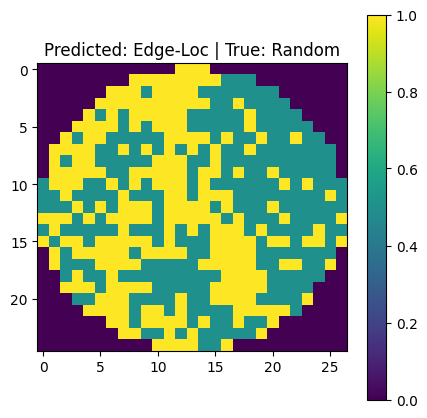

In [22]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(X_test) - 1)

sample = X_test[idx]
pred_idx = y_pred[idx]

pred_name = label_encoder.inverse_transform([pred_idx])[0]
true_name = label_encoder.inverse_transform([y_test[idx]])[0]

plt.figure(figsize=(5,5))
plt.imshow(sample.squeeze(), cmap='viridis')
plt.title(f"Predicted: {pred_name} | True: {true_name}")
plt.colorbar()
plt.show()

In [23]:
def fab_alert(defect_name):
    messages = {
        "Edge-Ring": "Edge-Ring detected — inspect coating/process uniformity.",
        "Edge-Loc": "Edge-Loc detected — inspect edge process stability or local edge issue.",
        "Center": "Center defect detected — inspect central process non-uniformity.",
        "Loc": "Localized defect detected — inspect tool-specific or site-specific anomaly.",
        "Scratch": "Scratch detected — inspect handling/tool contact sources.",
        "Random": "Random defect pattern detected — inspect contamination or stochastic process variation.",
        "Donut": "Donut defect detected — inspect radial process stability.",
        "Near-full": "Near-full defect detected — inspect severe process excursion or tool malfunction."
    }
    return messages.get(defect_name, "Unknown defect type — review wafer manually.")

print("Predicted defect:", pred_name)
print("Fab alert:", fab_alert(pred_name))

Predicted defect: Edge-Loc
Fab alert: Edge-Loc detected — inspect edge process stability or local edge issue.


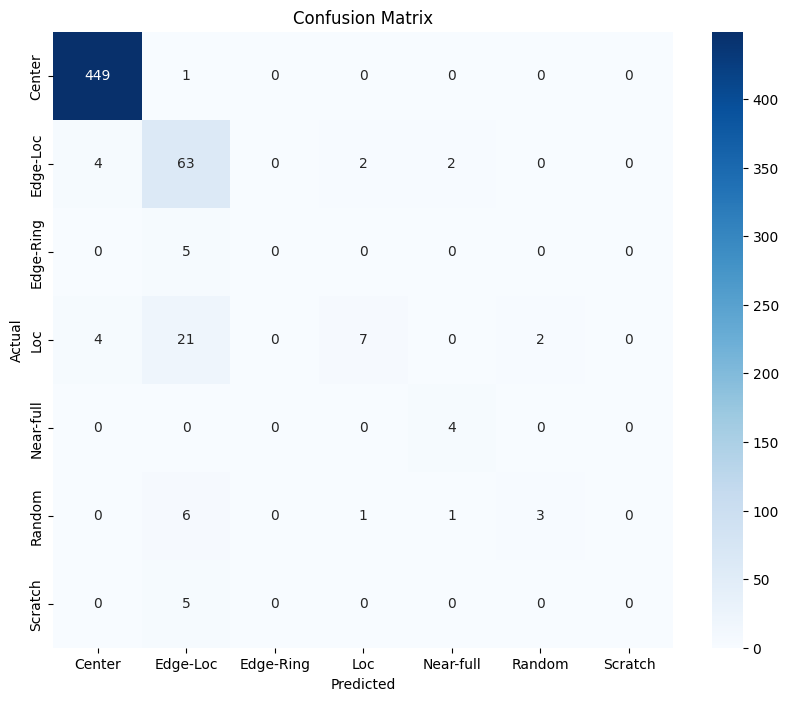

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
model.save("wafer_defect_classifier.h5")

In [26]:
model.save("wafer_defect_classifier.keras")